# Evaluation of the models

In [1]:
from mlp import *
import matplotlib.pyplot as plt
import seaborn as sns

tf.get_logger().setLevel('ERROR')

I0000 00:00:1782747275.735107   13214 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Model selection
- v1: base
- v2: early stopping + ethnicity based resampling
- v3: more complex prediction heads
- v4: 2 phase training

In [2]:
########## PARAMETERS ##########
version = 4
showSummary : bool = False
############################

model, history, metrics = LoadModelAndMetrics(base_path=f"models/gpu_v{version}")

if showSummary:
    model.summary()

W0000 00:00:1782747277.739029   13214 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Plots

Mean absolute age error: 5.721677303314209
Gender accuracy: 0.9192913385826772
Ethnicity accuracy: 0.796962879640045


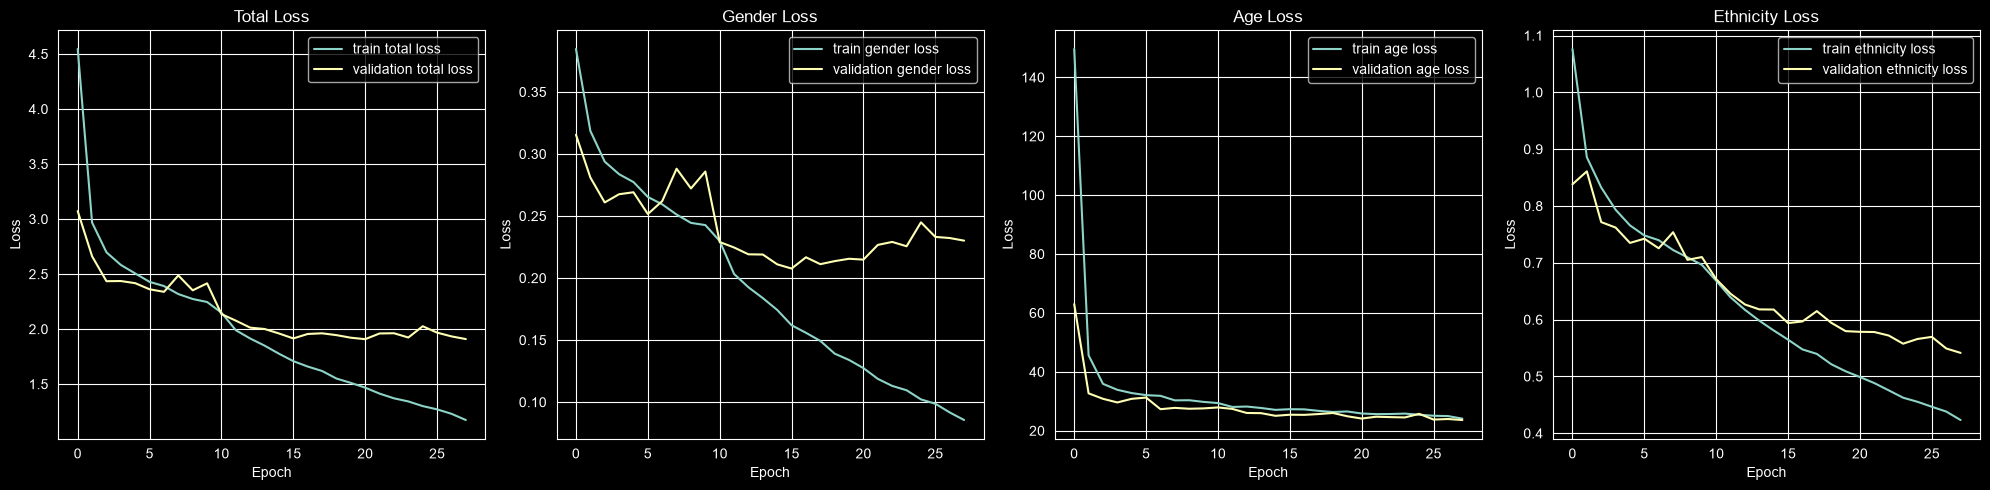

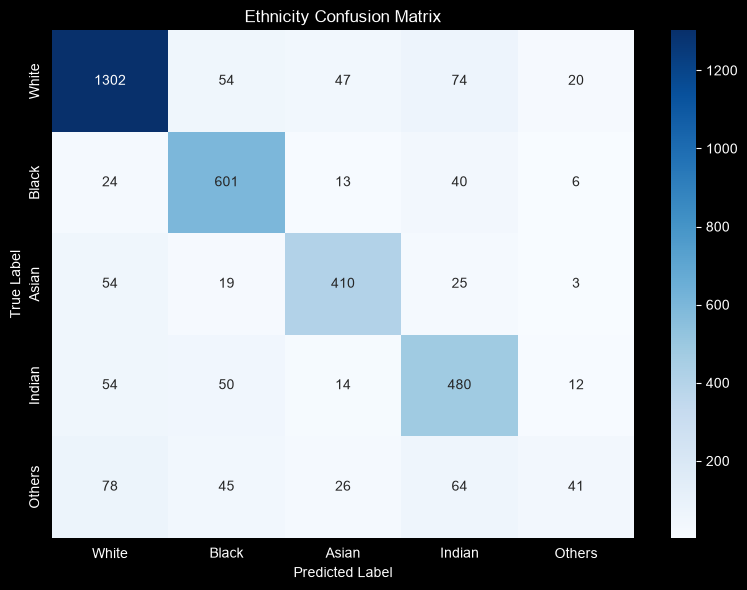

In [3]:
plt.figure(figsize=(20, 5))

# Plotting total loss
plt.subplot(1, 4, 1)
plt.plot(history.get("loss", []), label="train total loss")
plt.plot(history.get("val_loss", []), label="validation total loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting age loss
plt.subplot(1, 4, 3)
plt.plot(history.get("age_loss", []), label="train age loss")
plt.plot(history.get("val_age_loss", []), label="validation age loss")
plt.title("Age Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting gender loss
plt.subplot(1, 4, 2)
plt.plot(history.get("gender_loss", []), label="train gender loss")
plt.plot(history.get("val_gender_loss", []), label="validation gender loss")
plt.title("Gender Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting ethnicity loss
plt.subplot(1, 4, 4)
plt.plot(history.get("ethnicity_loss", []), label="train ethnicity loss")
plt.plot(history.get("val_ethnicity_loss", []), label="validation ethnicity loss")
plt.title("Ethnicity Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

# Print metrics
#for key in metrics:
#    if key != "confusion_matrix":
#        print(f"Key: {key} : value: {metrics[key]}")

print(f"Mean absolute age error: {metrics['age_mae']}")
print(f"Gender accuracy: {metrics['gender_accuracy']}")
print(f"Ethnicity accuracy: {metrics['ethnicity_accuracy']}")

# Print confusion matrix

cm = metrics['confusion_matrix']
plt.figure(figsize=(8, 6))
labels = ['White', 'Black', 'Asian', 'Indian', 'Others']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Ethnicity Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()